In [9]:
import pandas as pd
import numpy as np
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import class_weight

# Load the dataset (replace the path with your actual file path)
df = pd.read_csv('/content/sample_data/alzheimers_disease_data.csv')

In [10]:
df.dtypes

,0
PatientID,int64
Age,int64
Gender,int64
Ethnicity,int64
EducationLevel,int64
BMI,float64
Smoking,int64
AlcoholConsumption,float64
PhysicalActivity,float64
DietQuality,float64


In [11]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
print("Unique Values and Counts for Potential Categorical Columns (int64 dtype):")
print("------------------------------------------------------------------")

for column in df.columns:
    if df[column].dtype == 'int64':
        unique_count = df[column].nunique()
        print(f"\nColumn: {column}, Number of Unique Values: {unique_count}")
        if unique_count <= 10:
            print(df[column].value_counts())

Unique Values and Counts for Potential Categorical Columns (int64 dtype):
------------------------------------------------------------------

Column: PatientID, Number of Unique Values: 2149

Column: Age, Number of Unique Values: 31

Column: Gender, Number of Unique Values: 2
Gender
1    1088
0    1061
Name: count, dtype: int64

Column: Ethnicity, Number of Unique Values: 4
Ethnicity
0    1278
1     454
3     211
2     206
Name: count, dtype: int64

Column: EducationLevel, Number of Unique Values: 4
EducationLevel
1    854
2    636
0    446
3    213
Name: count, dtype: int64

Column: Smoking, Number of Unique Values: 2
Smoking
0    1529
1     620
Name: count, dtype: int64

Column: FamilyHistoryAlzheimers, Number of Unique Values: 2
FamilyHistoryAlzheimers
0    1607
1     542
Name: count, dtype: int64

Column: CardiovascularDisease, Number of Unique Values: 2
CardiovascularDisease
0    1839
1     310
Name: count, dtype: int64

Column: Diabetes, Number of Unique Values: 2
Diabetes
0    1

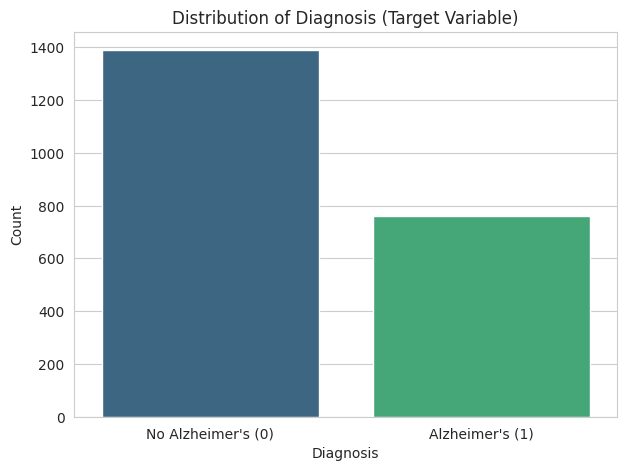

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each unique value in the 'Diagnosis' column
diagnosis_counts = df['Diagnosis'].value_counts()

# Create a bar plot
plt.figure(figsize=(7, 5))
sns.barplot(x=diagnosis_counts.index, y=diagnosis_counts.values, hue=diagnosis_counts.index, palette='viridis', legend=False)

# Label the x-axis, y-axis, and add a title
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.title('Distribution of Diagnosis (Target Variable)')
plt.xticks(ticks=[0, 1], labels=['No Alzheimer\'s (0)', 'Alzheimer\'s (1)'])

# Display the plot
plt.show()

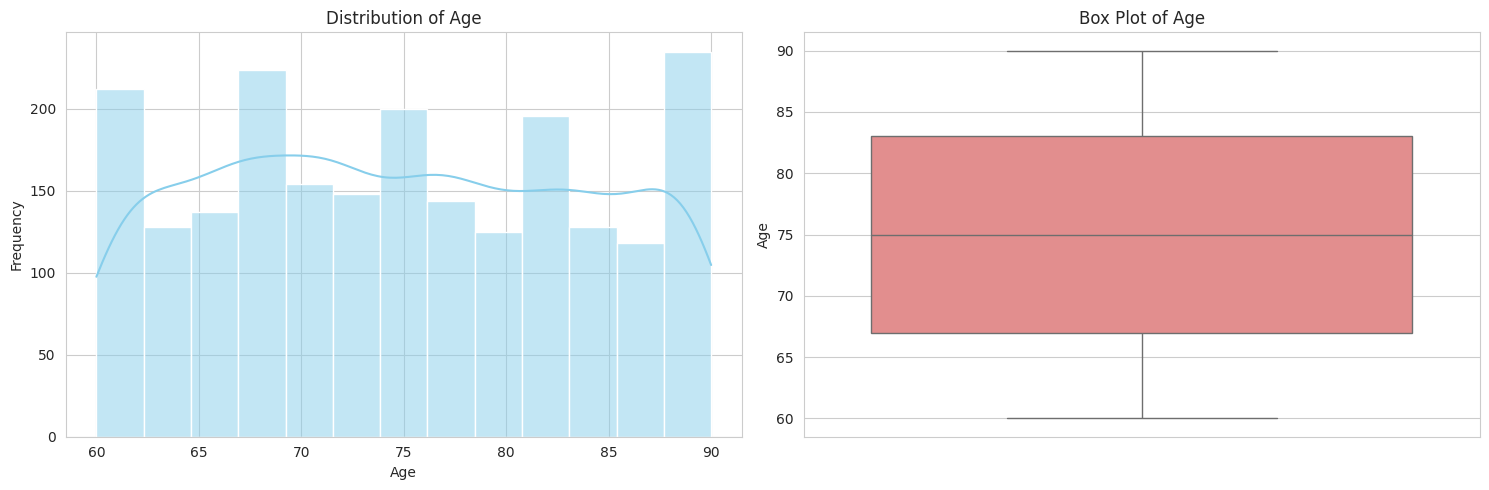

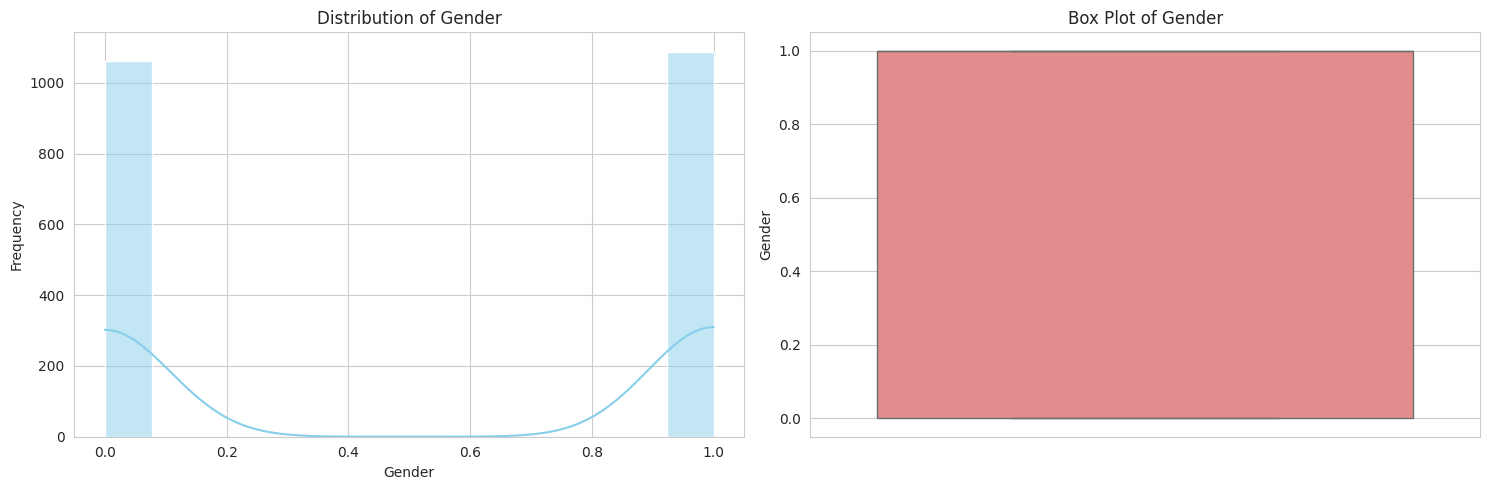

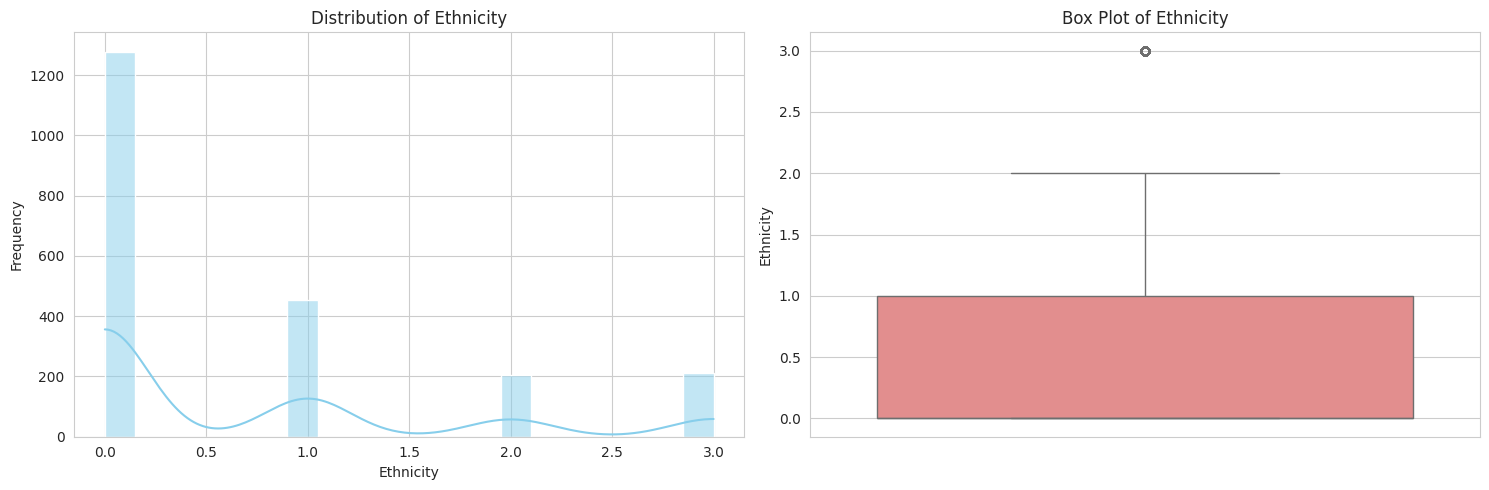

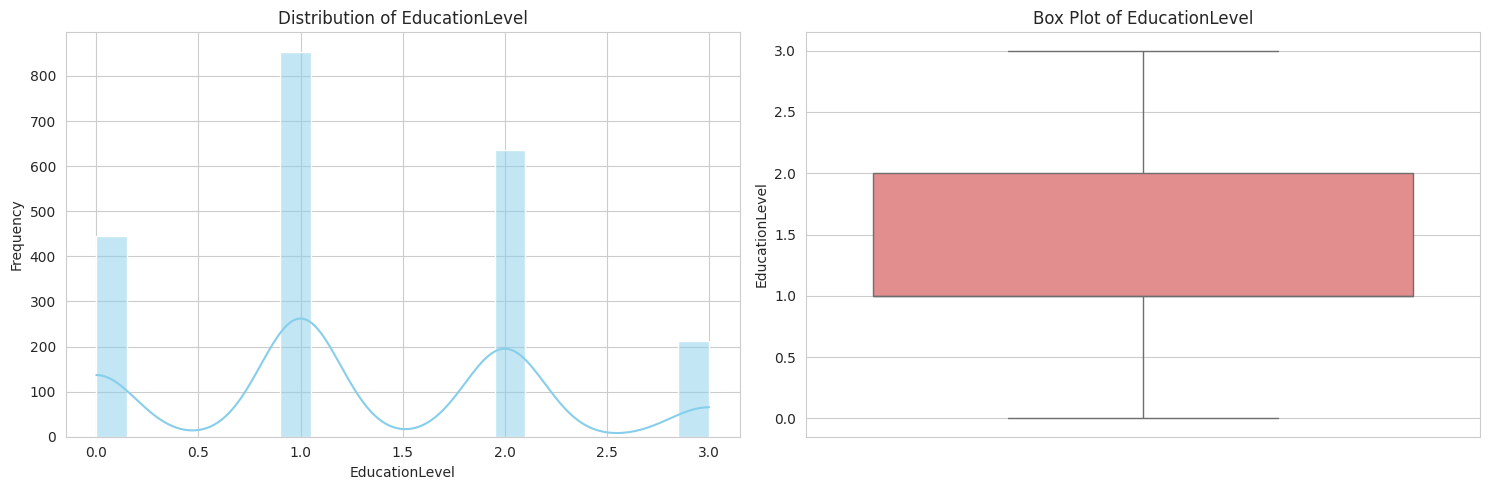

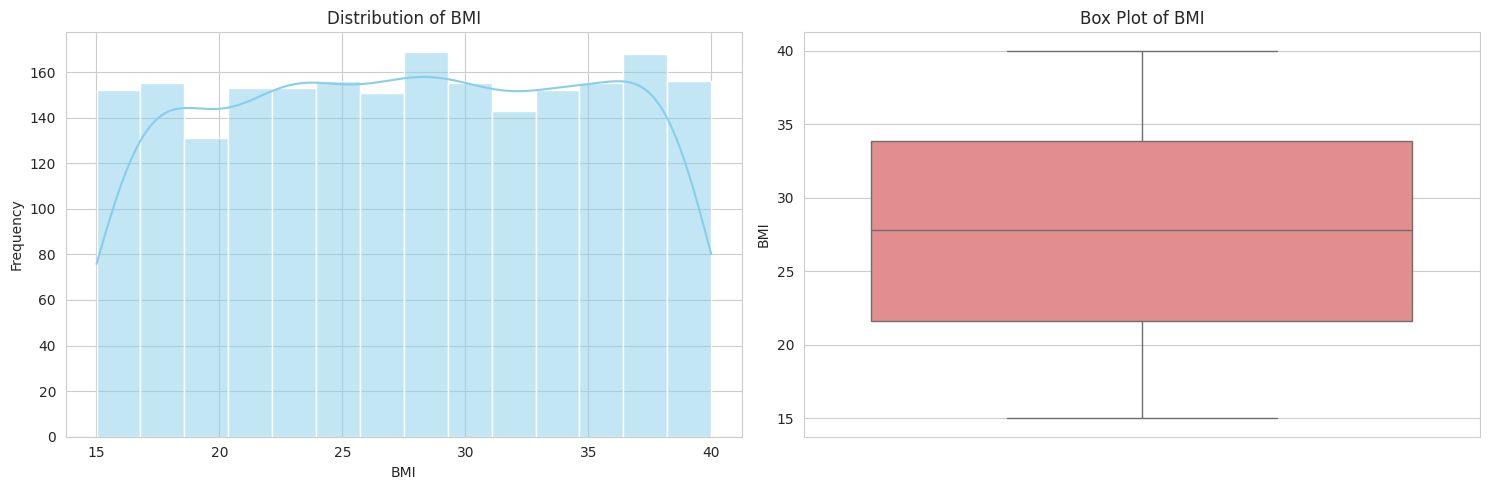

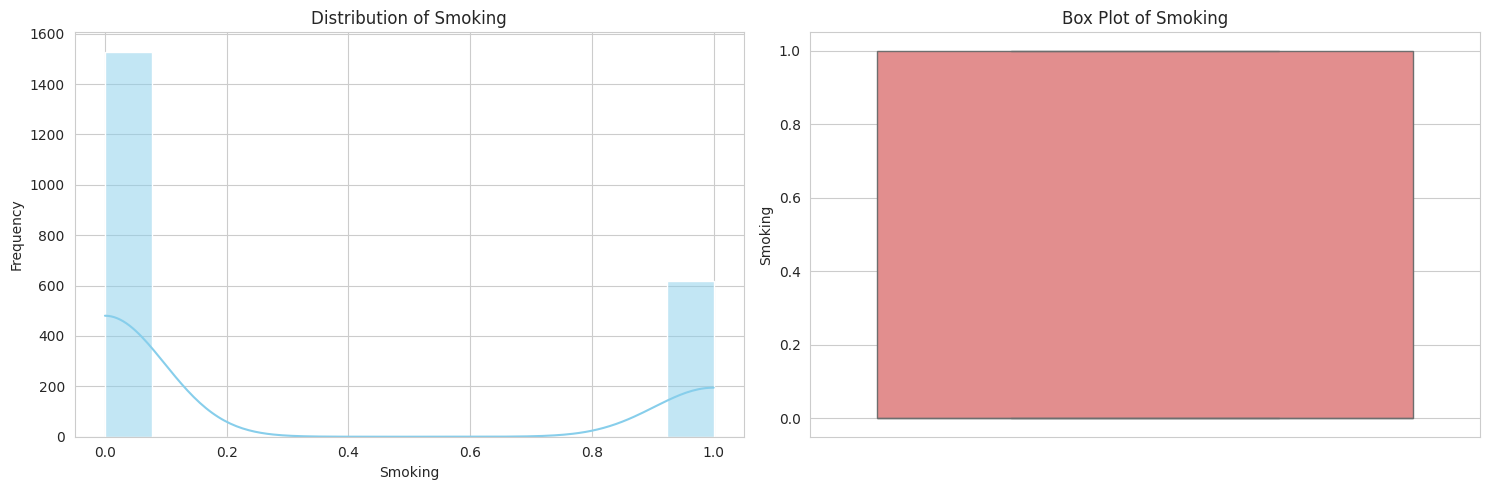

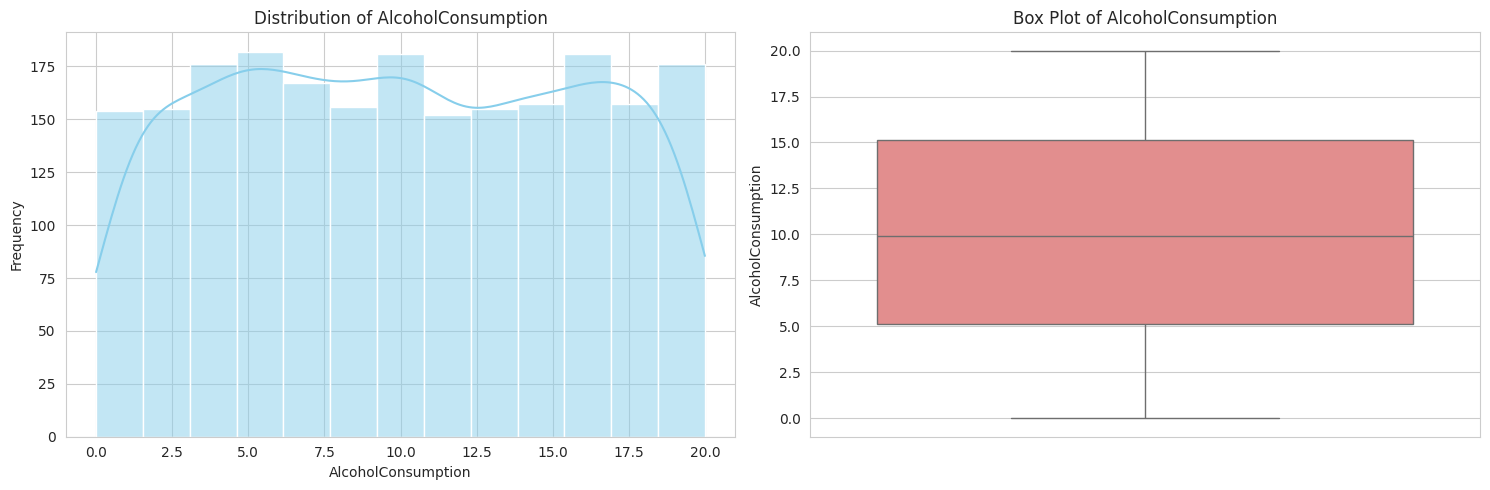

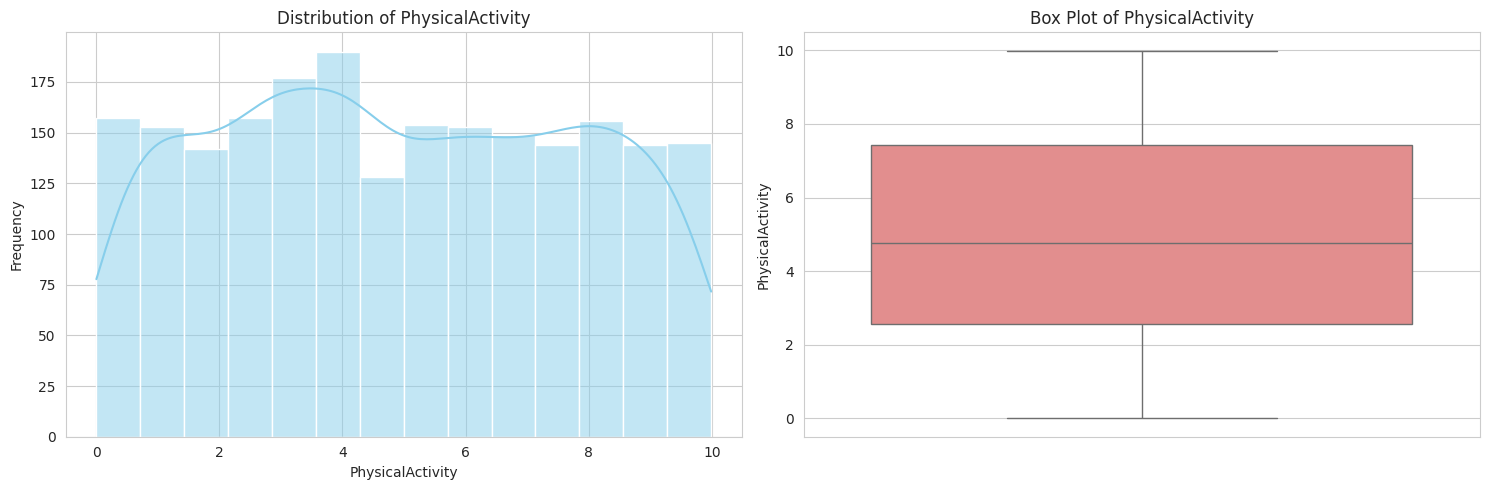

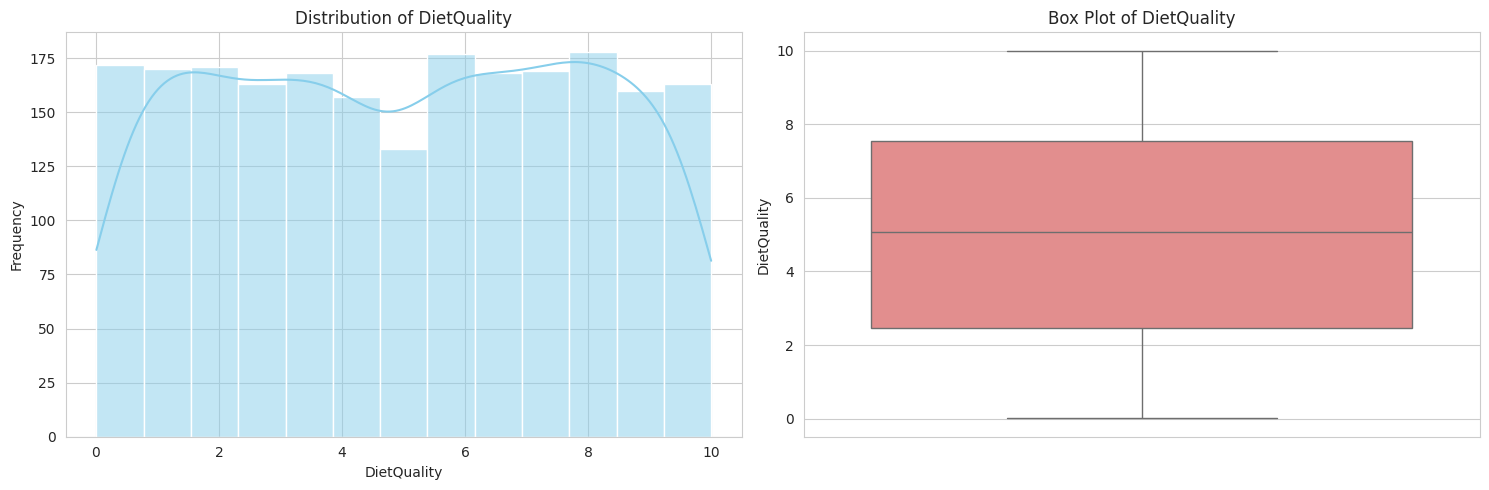

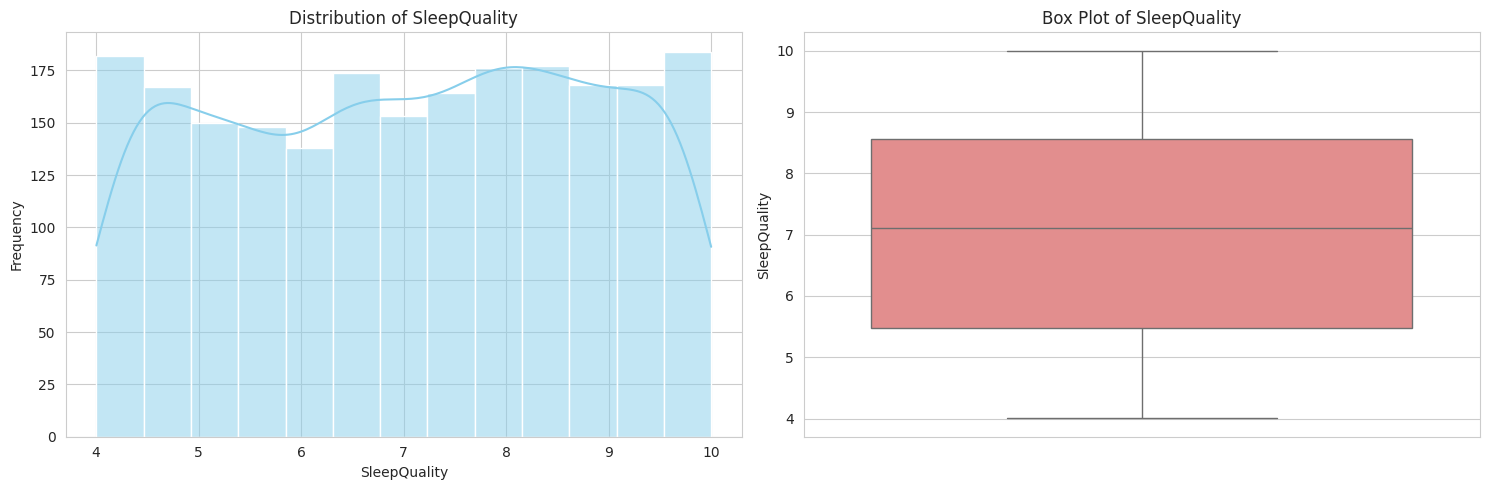

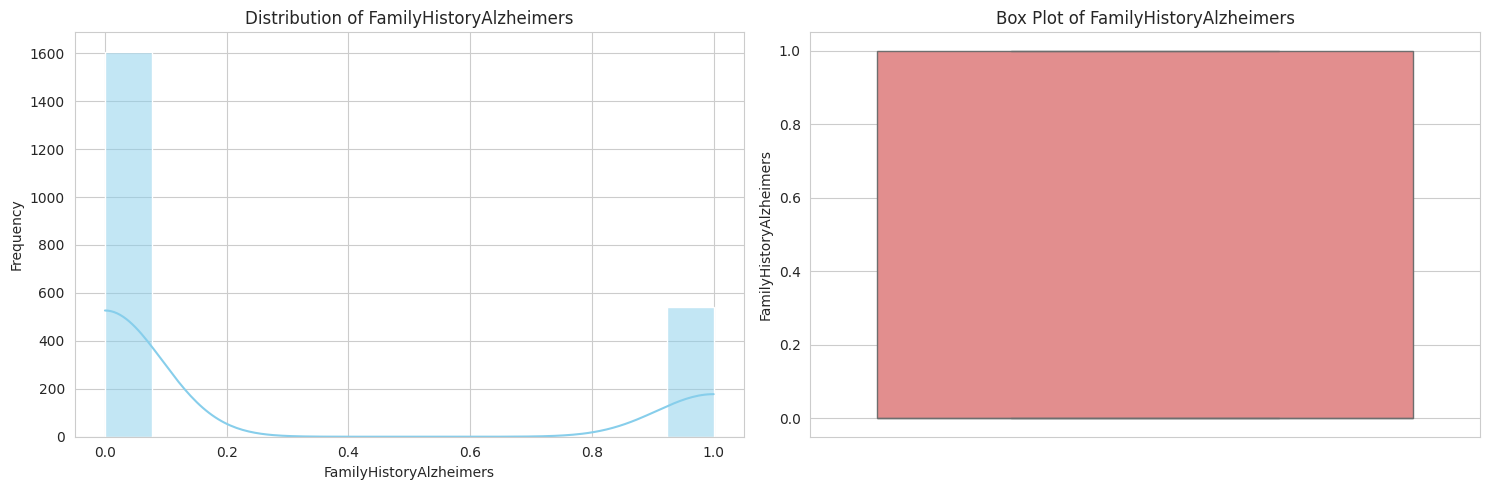

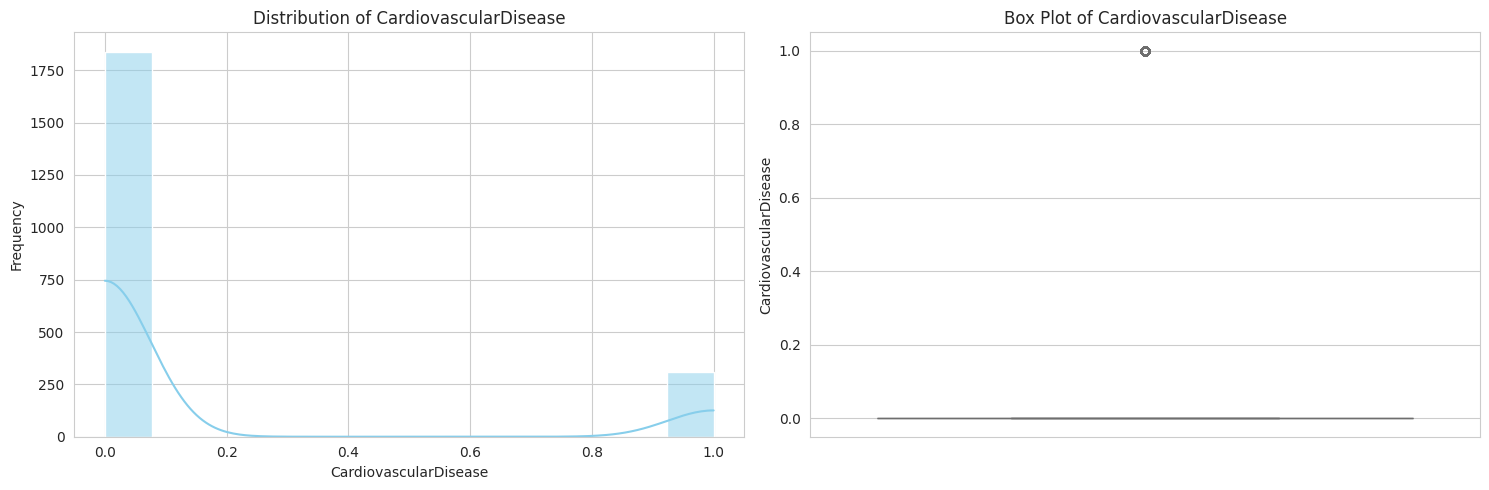

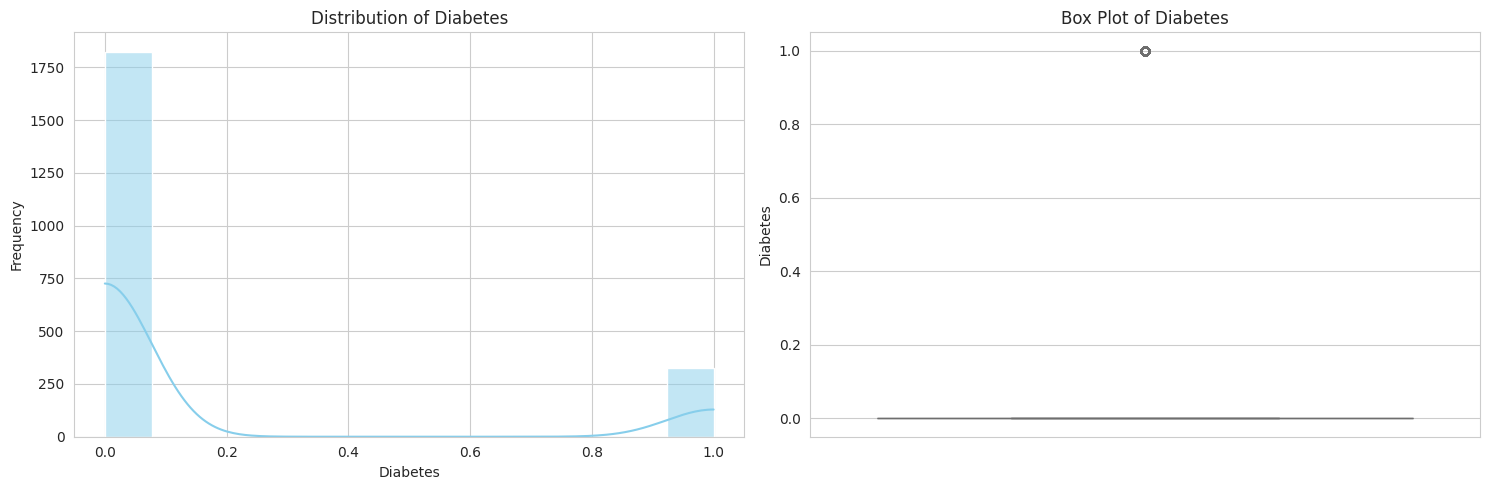

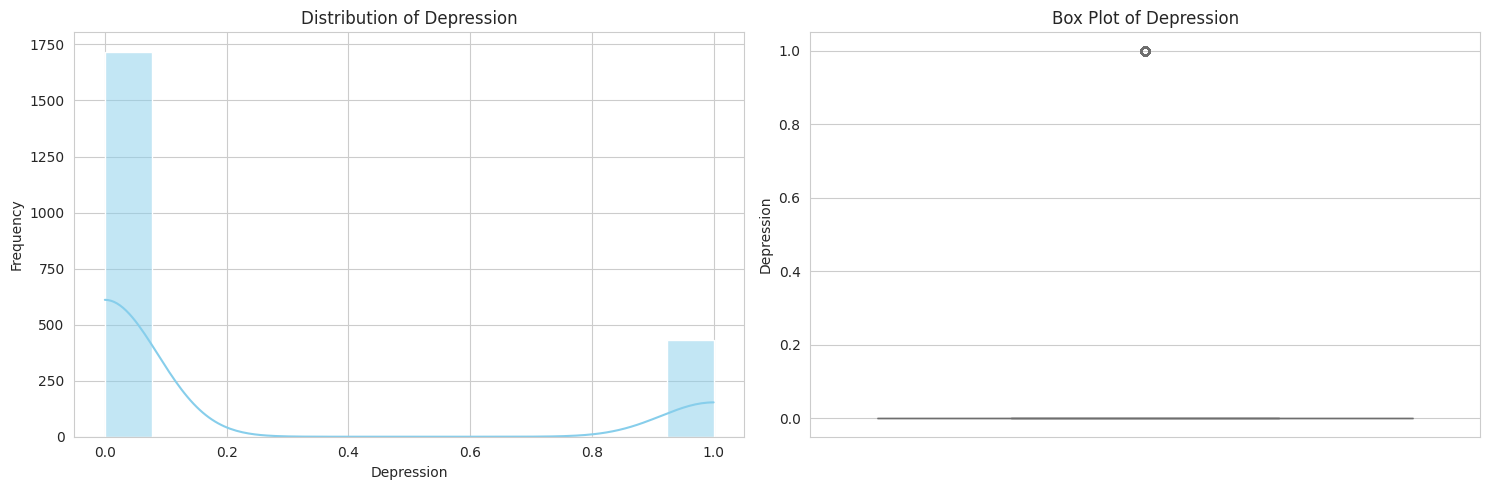

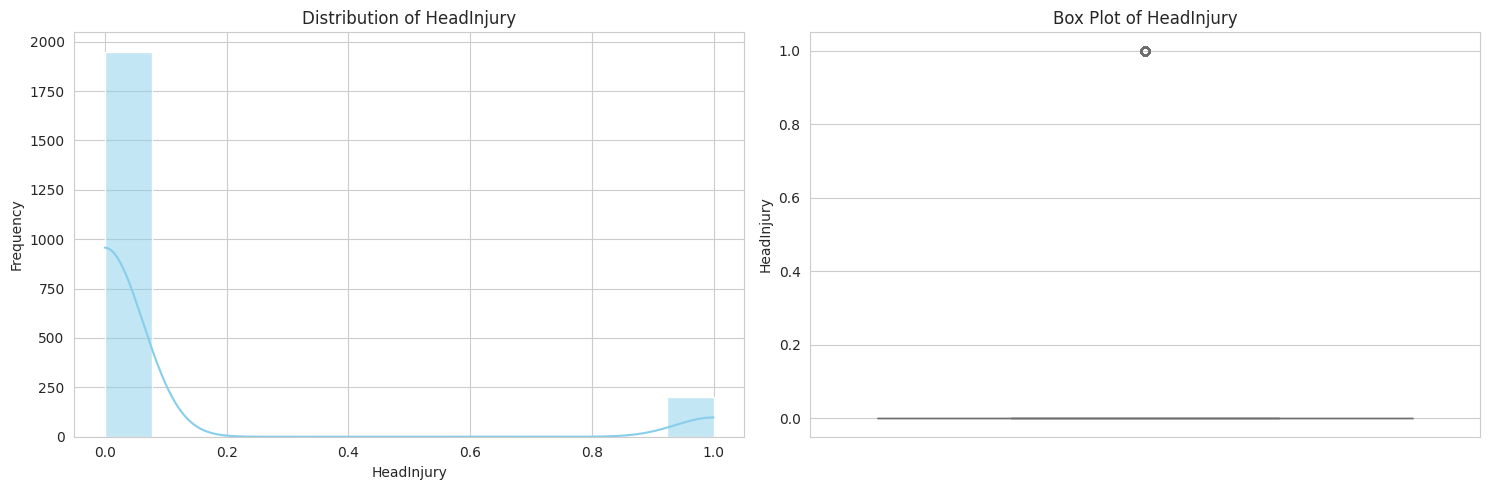

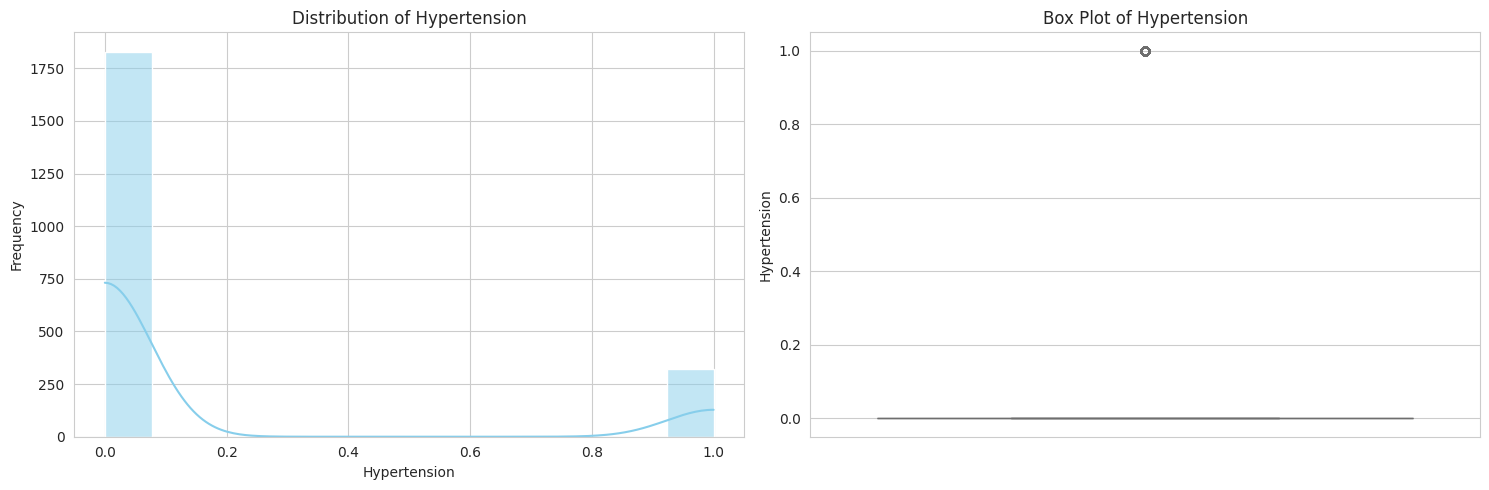

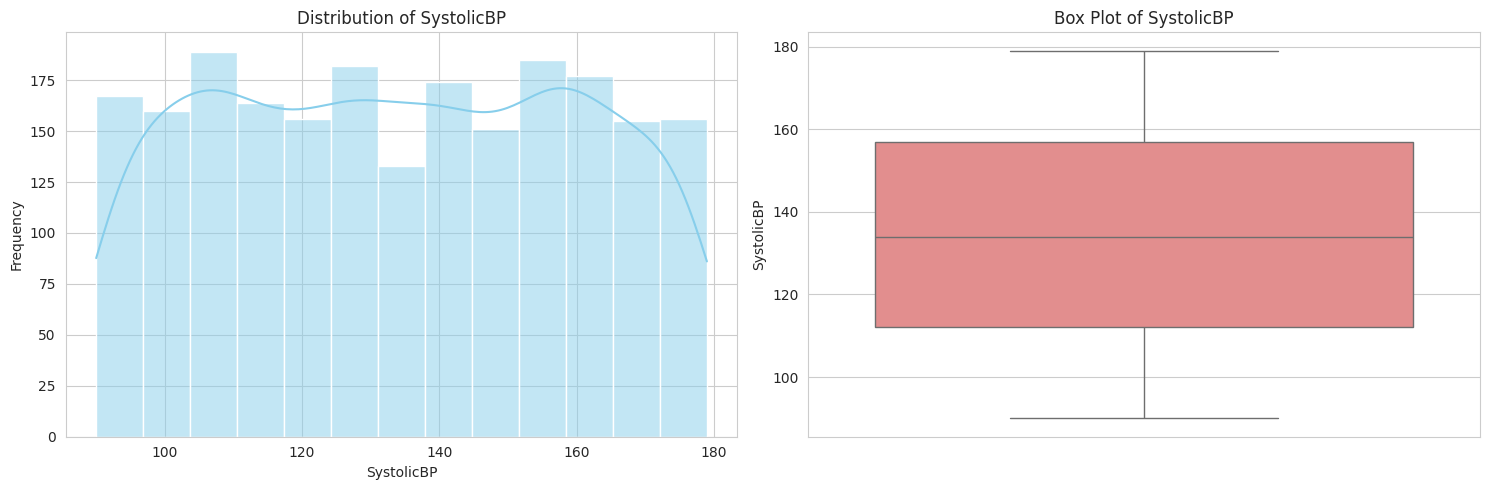

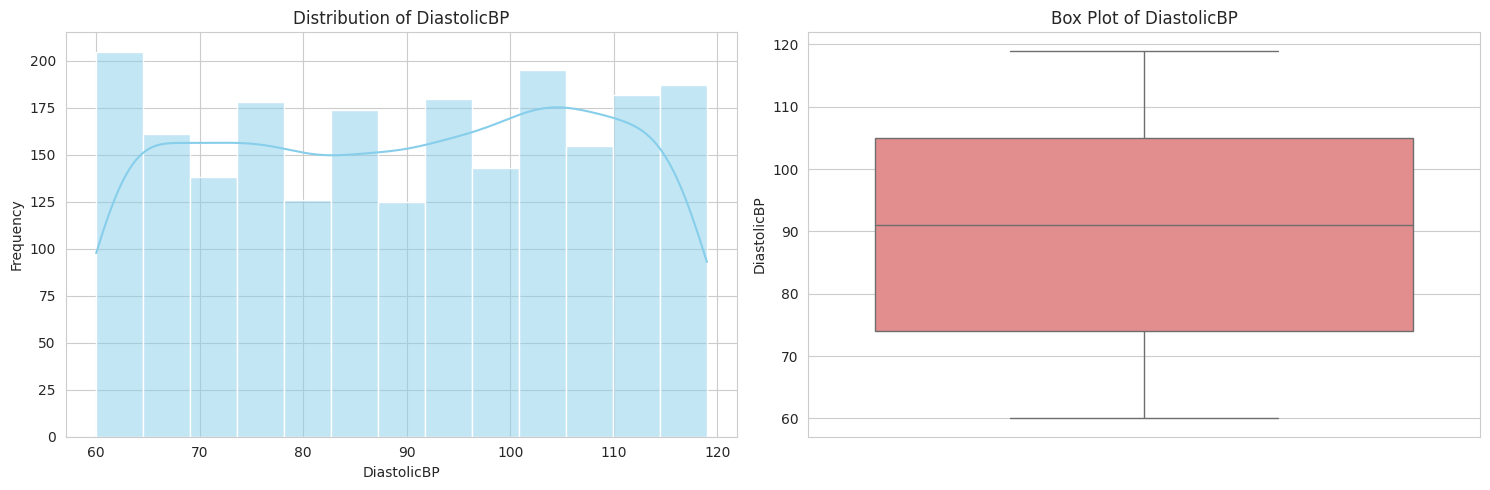

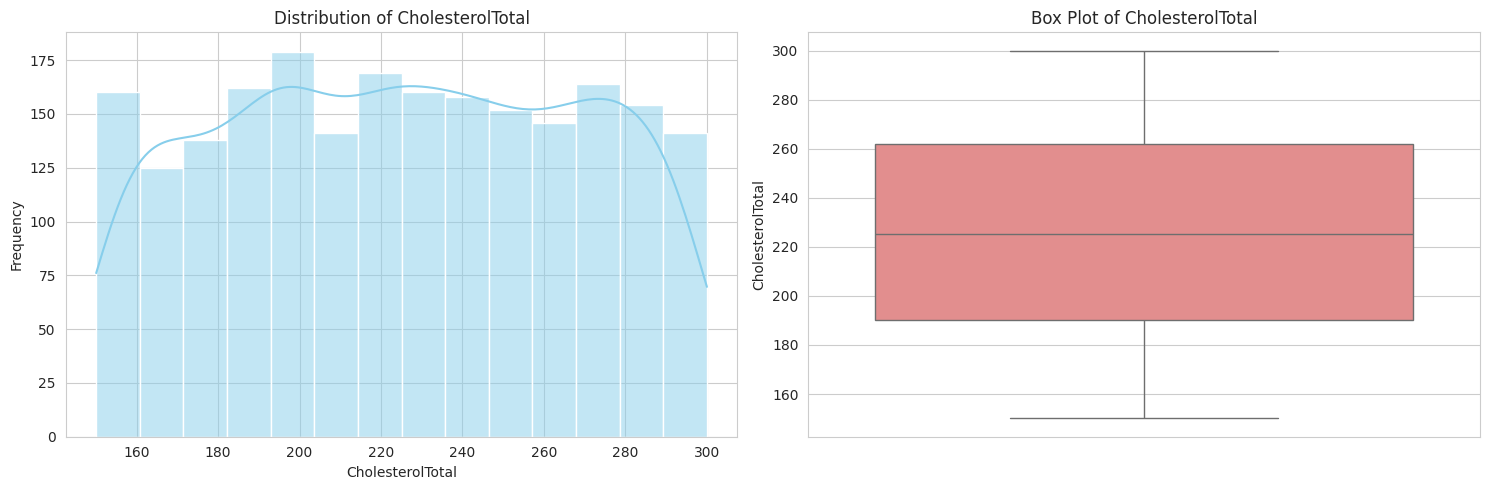

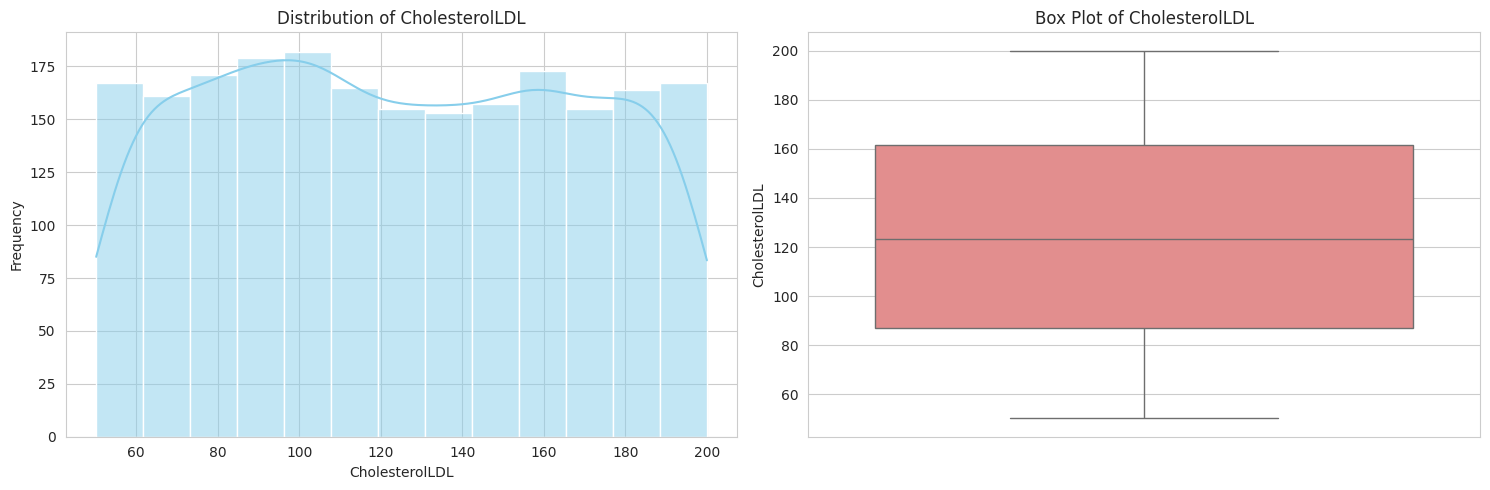

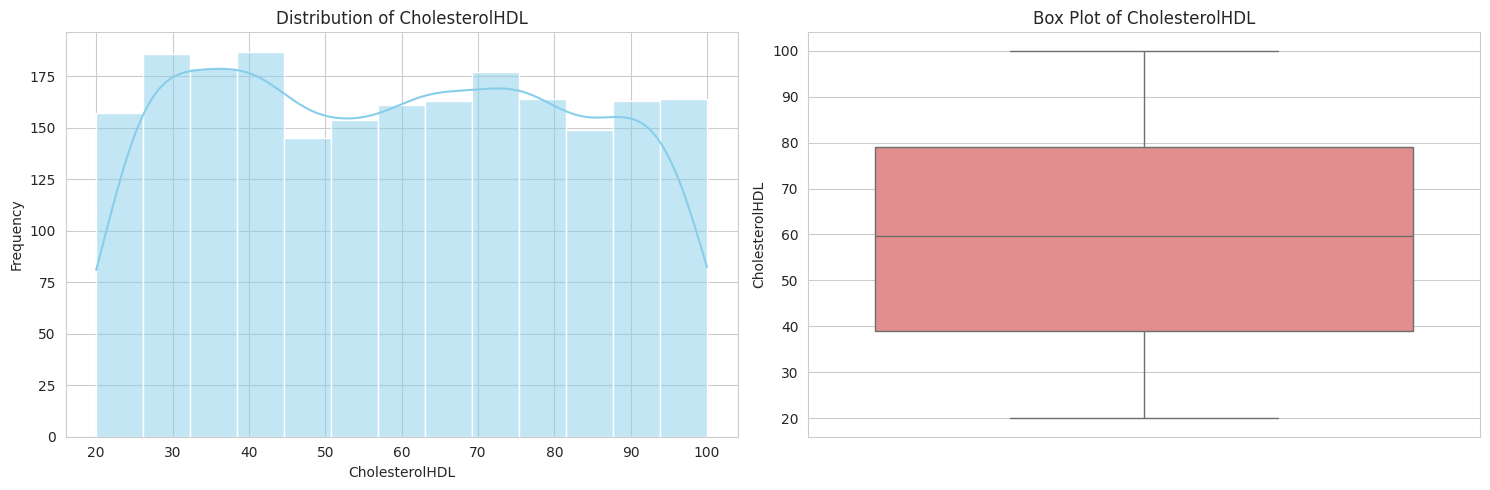

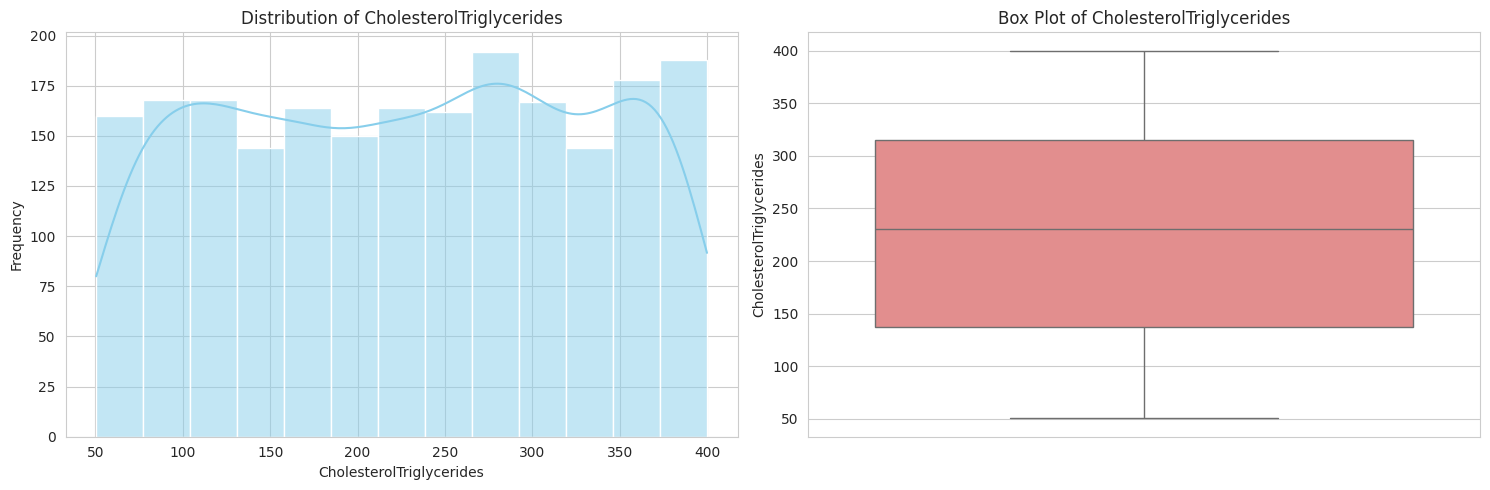

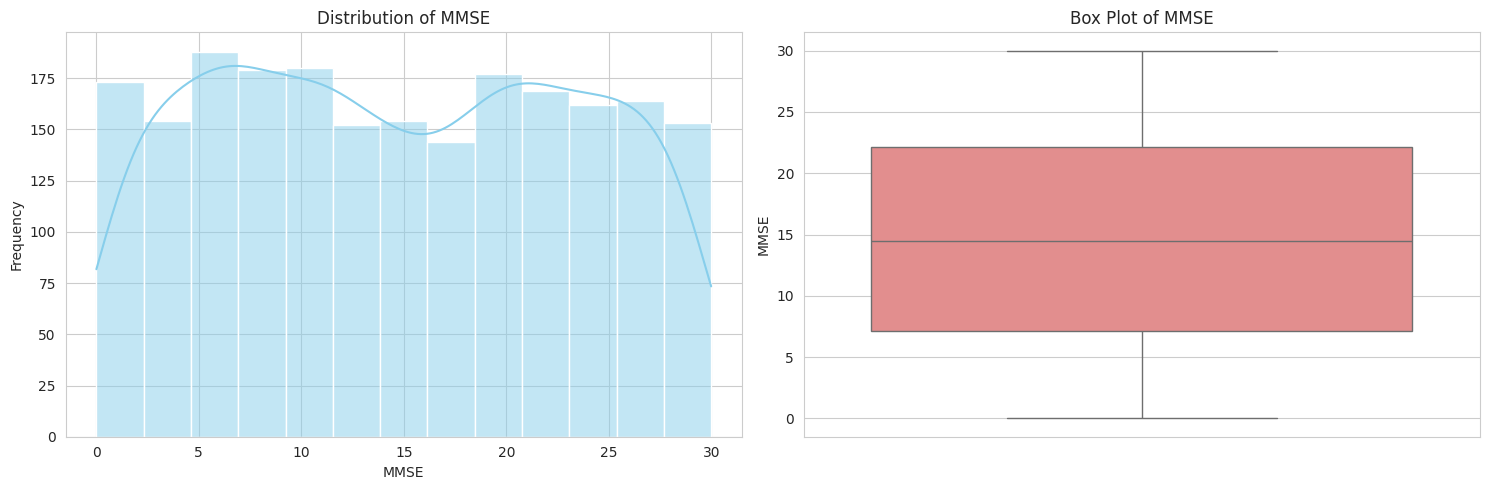

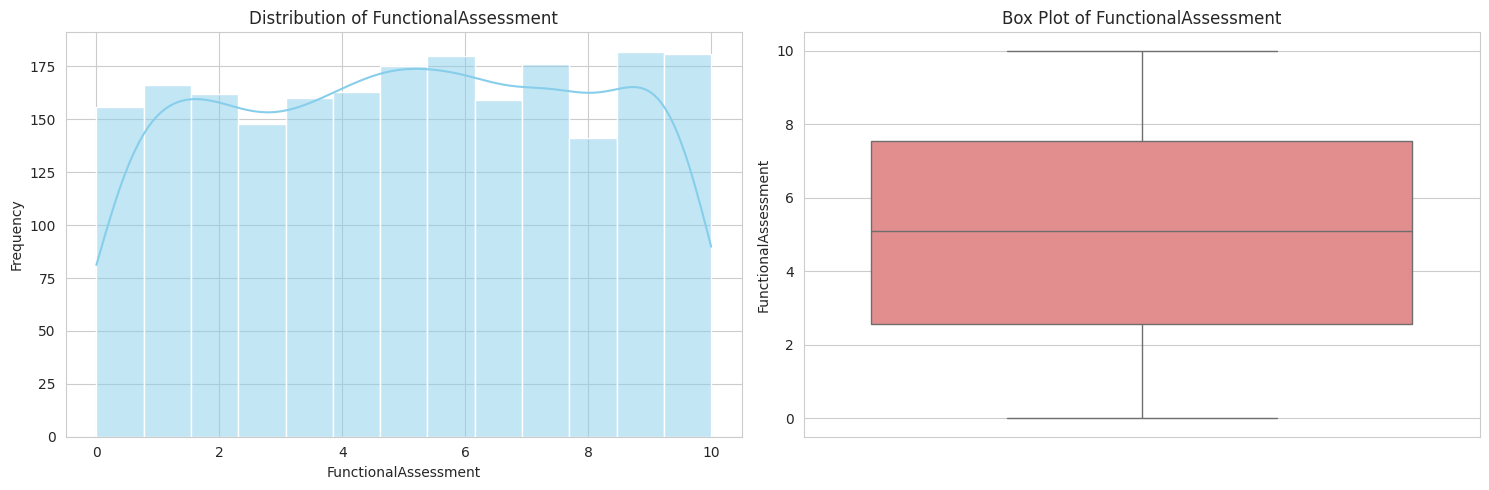

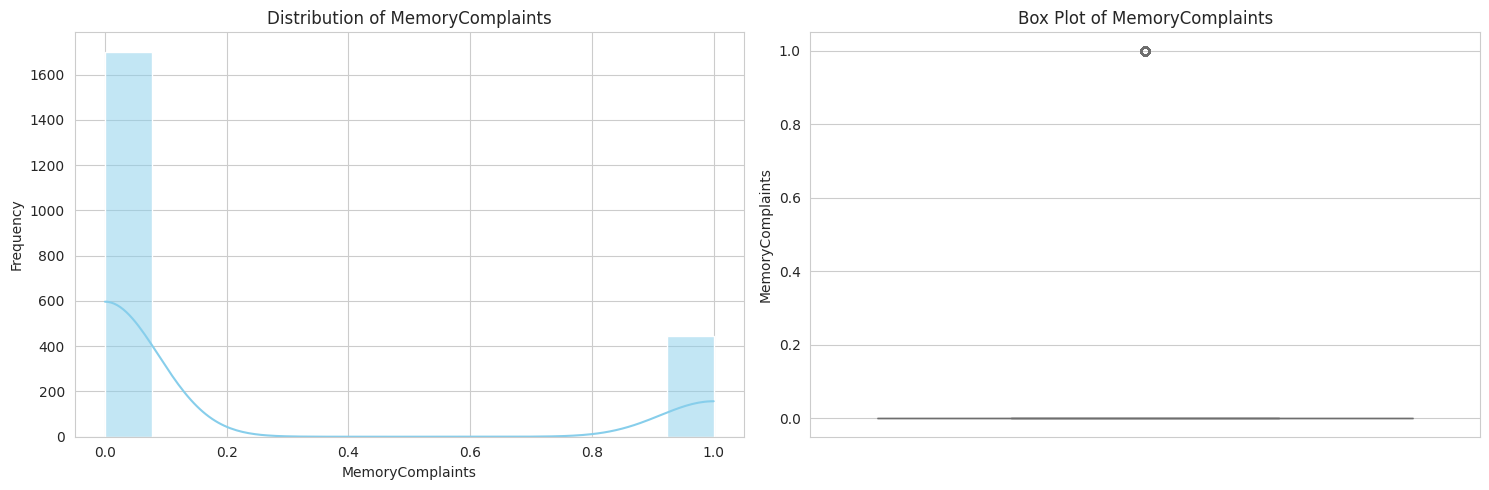

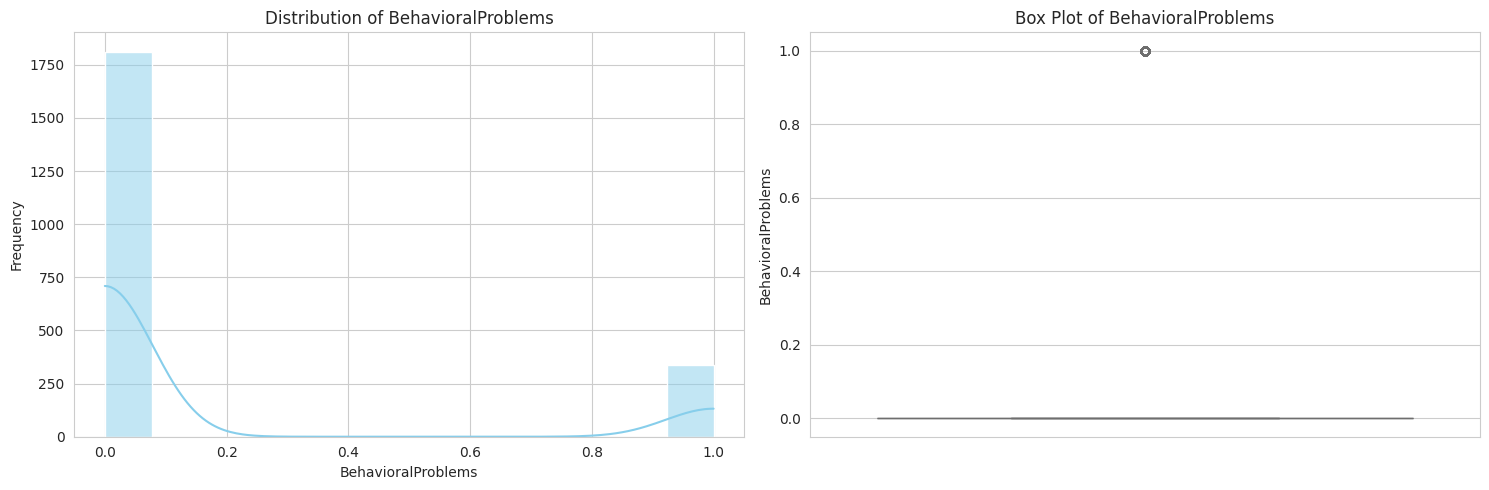

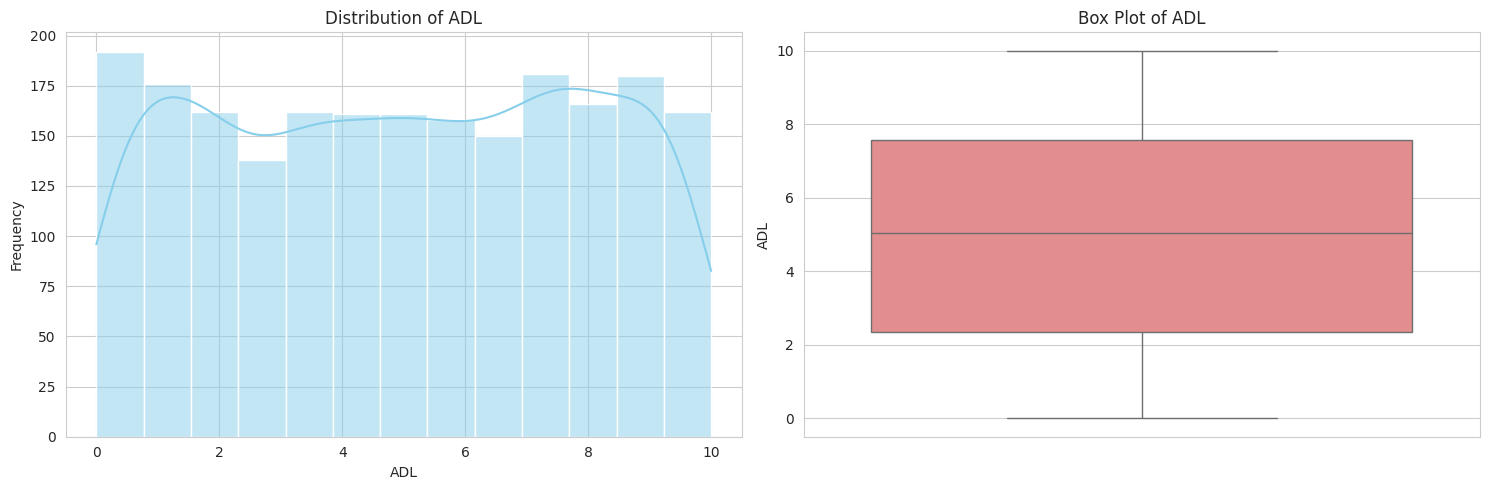

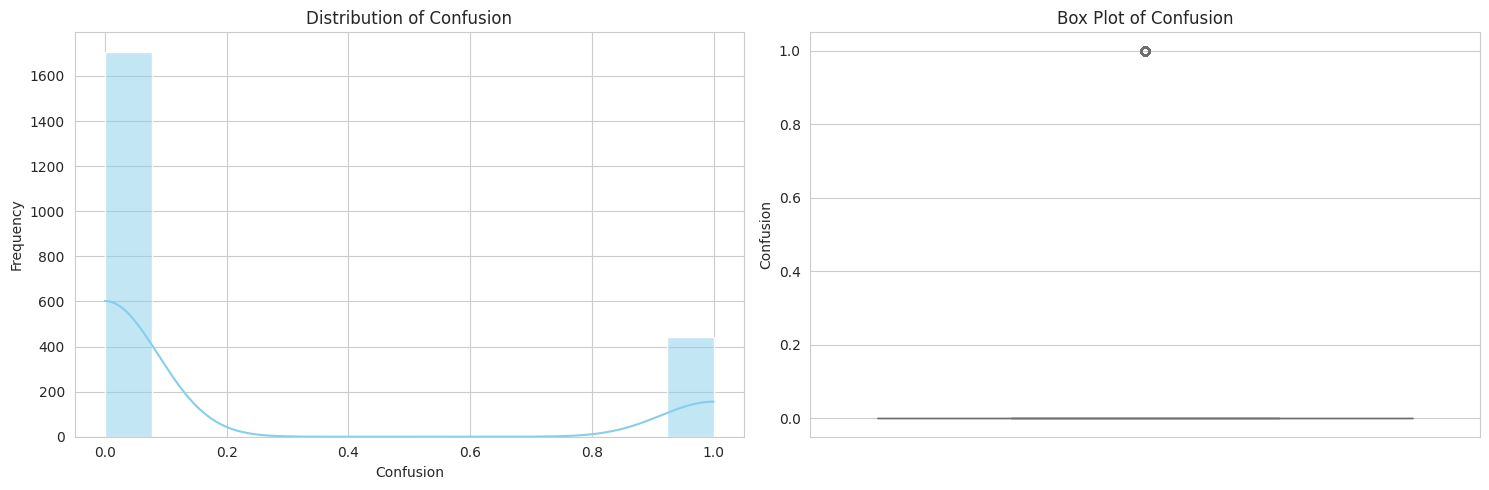

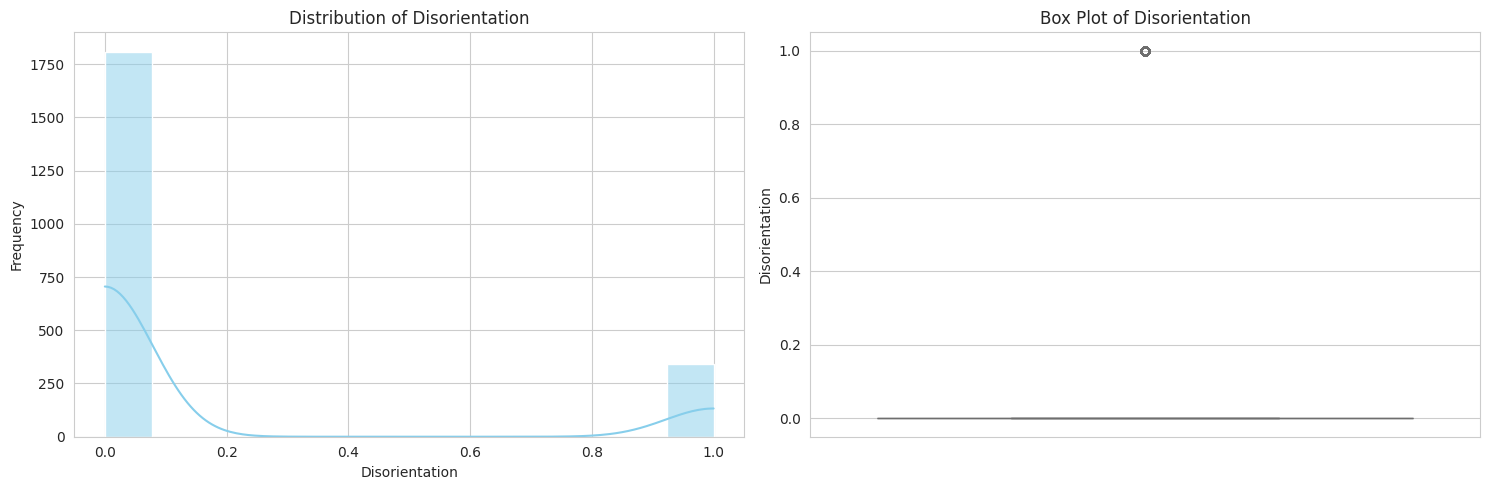

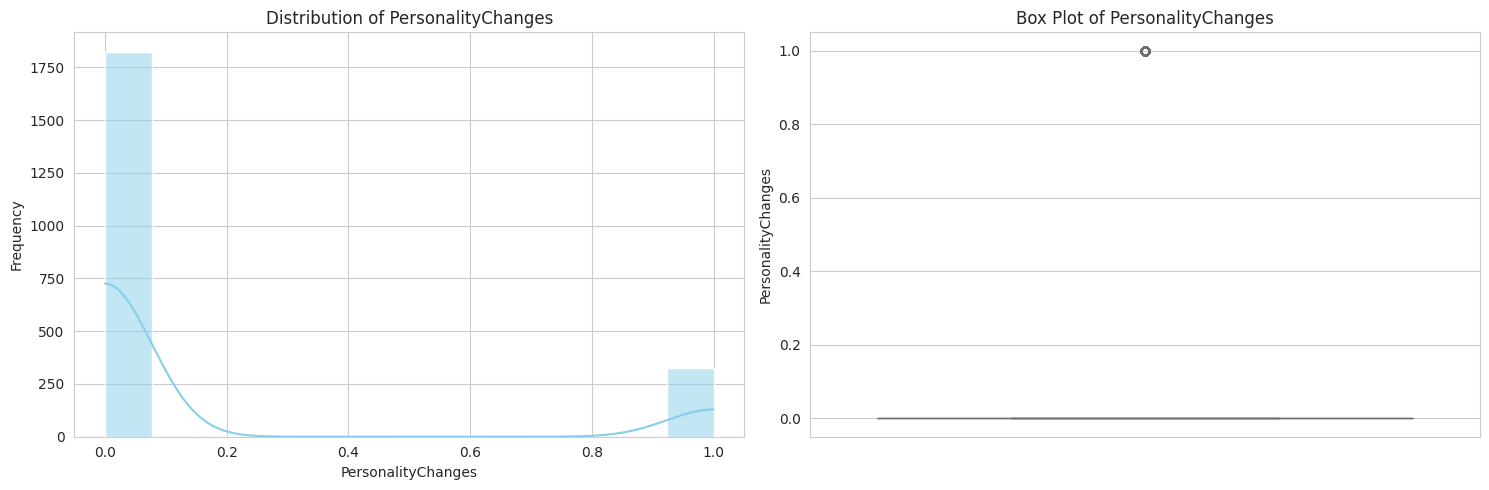

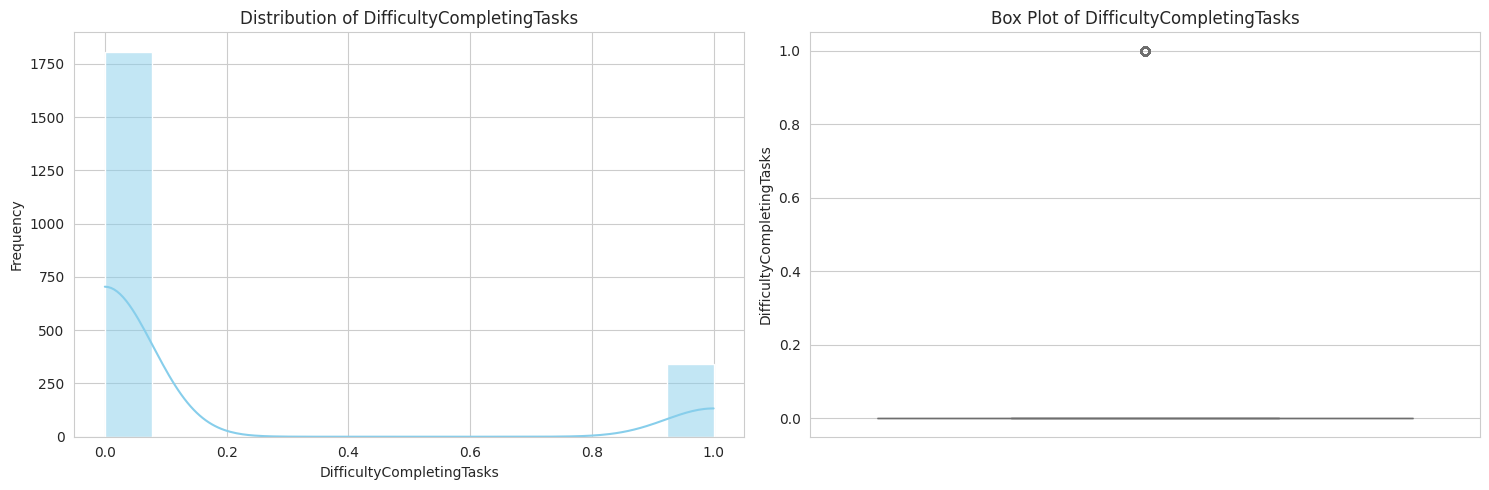

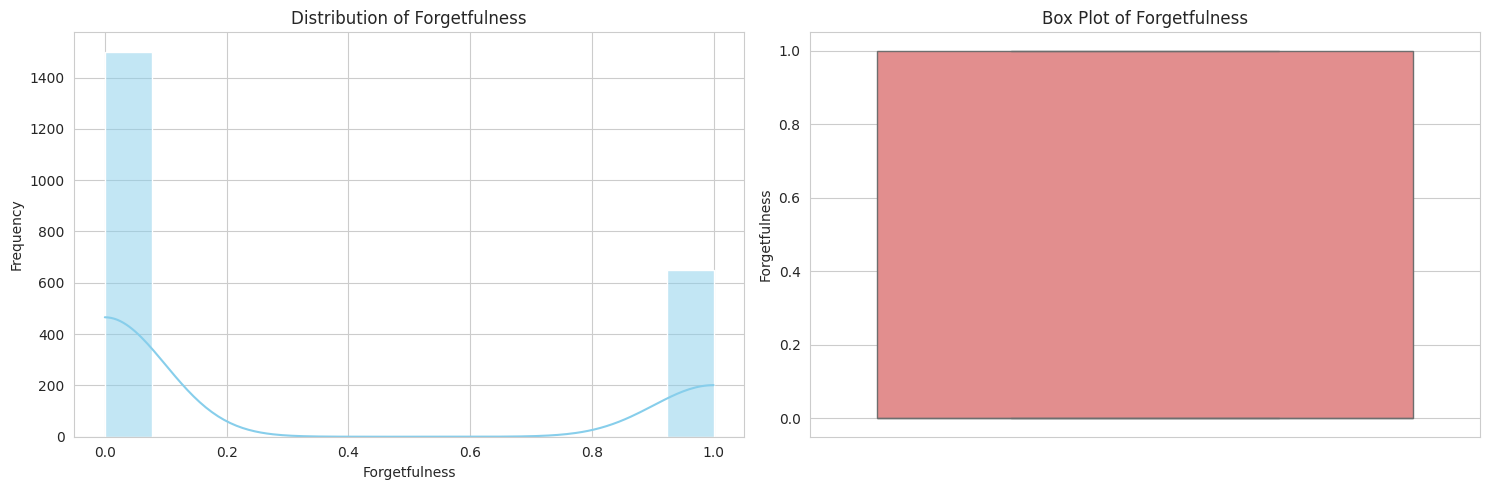

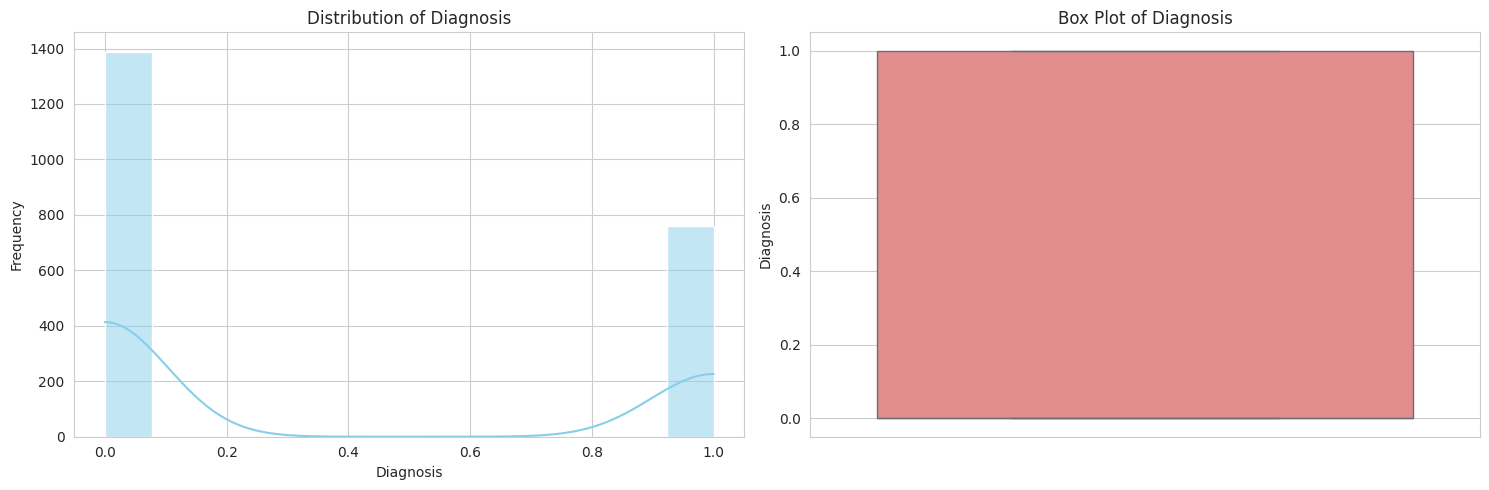

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns, excluding 'PatientID'
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'PatientID' in numerical_cols:
    numerical_cols.remove('PatientID')

# Set up the plotting style
sns.set_style("whitegrid")

# Plot histograms and box plots for each numerical feature
for column in numerical_cols:
    plt.figure(figsize=(15, 5))

    # Histogram subplot
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    sns.histplot(df[column], kde=True, color='skyblue')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Box plot subplot
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    sns.boxplot(y=df[column], color='lightcoral')
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

## Analyze Feature Correlations



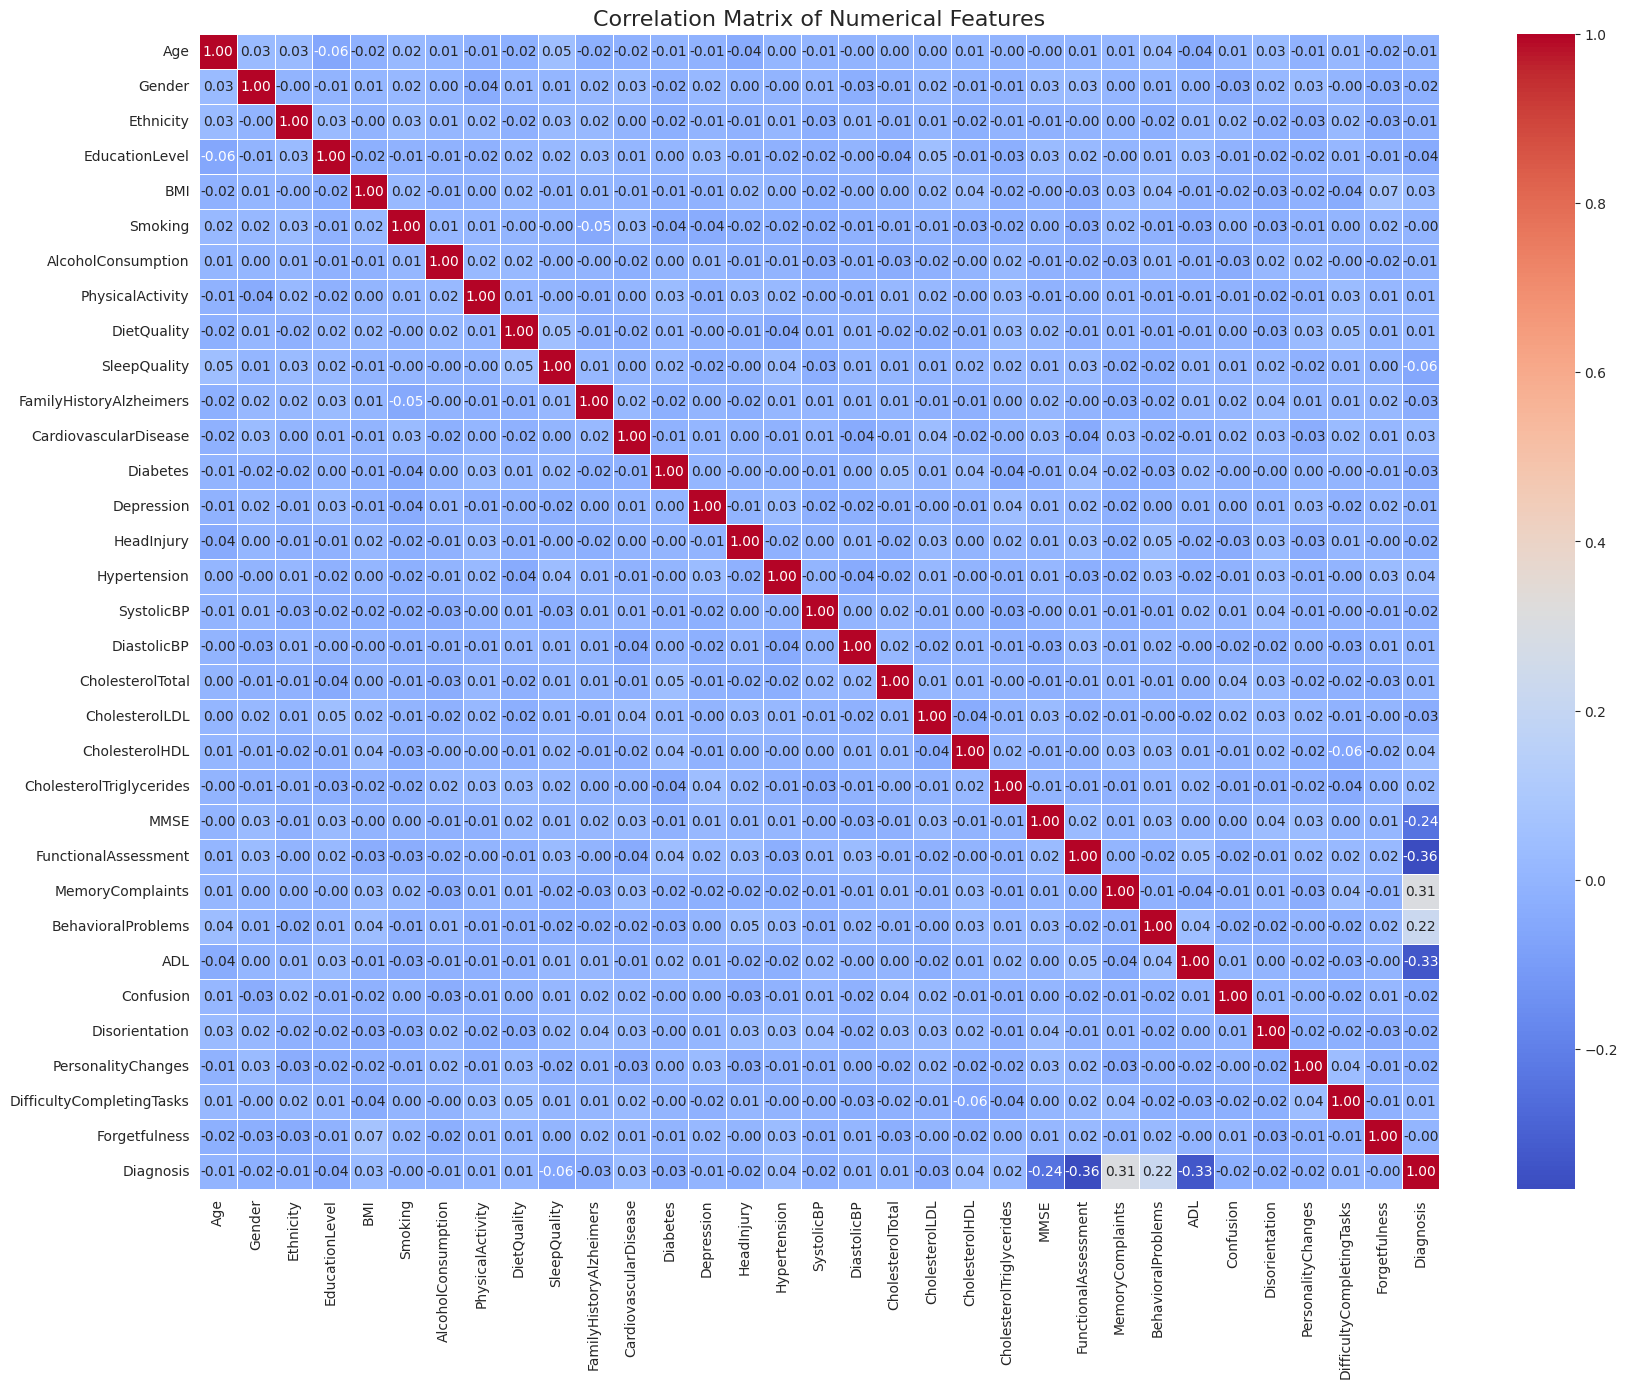

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Diagnosis' is in numerical_cols for correlation if not already present
if 'Diagnosis' not in numerical_cols:
    numerical_cols.append('Diagnosis')

# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 15))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)

# Add a title to the heatmap
plt.title('Correlation Matrix of Numerical Features', fontsize=16)

# Display the plot
plt.show()

## Examine Categorical Features vs. Diagnosis



Identified categorical columns for plotting: ['Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']


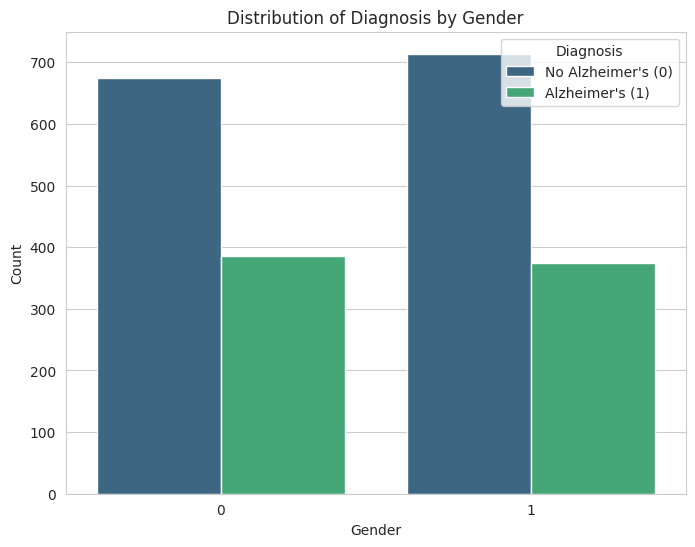

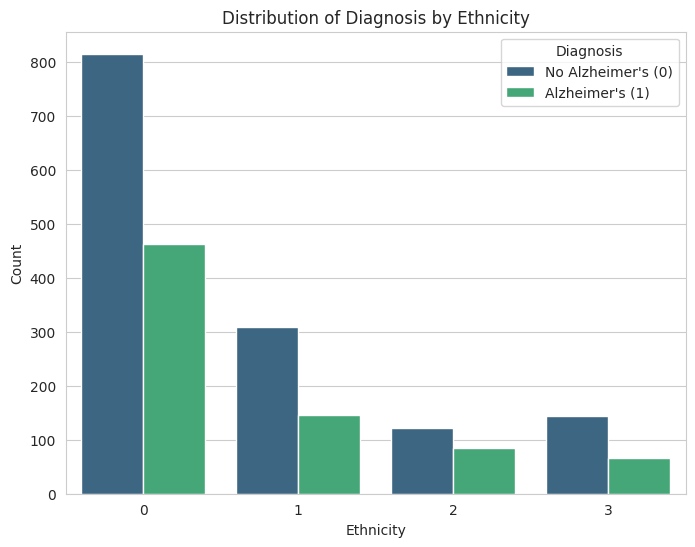

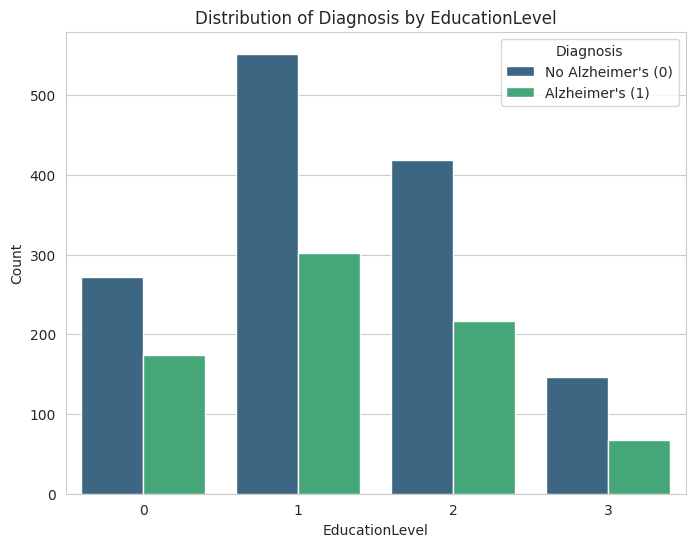

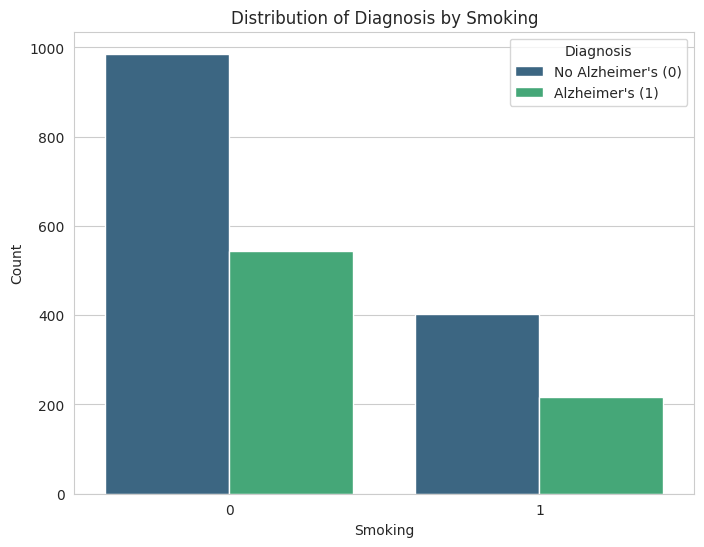

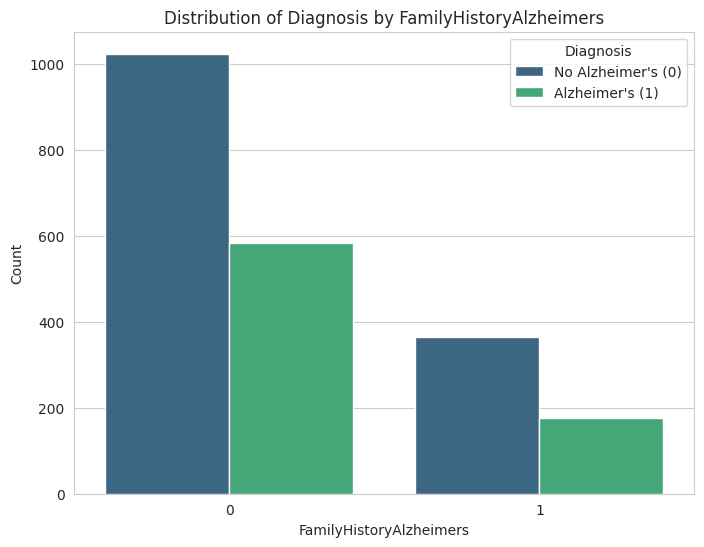

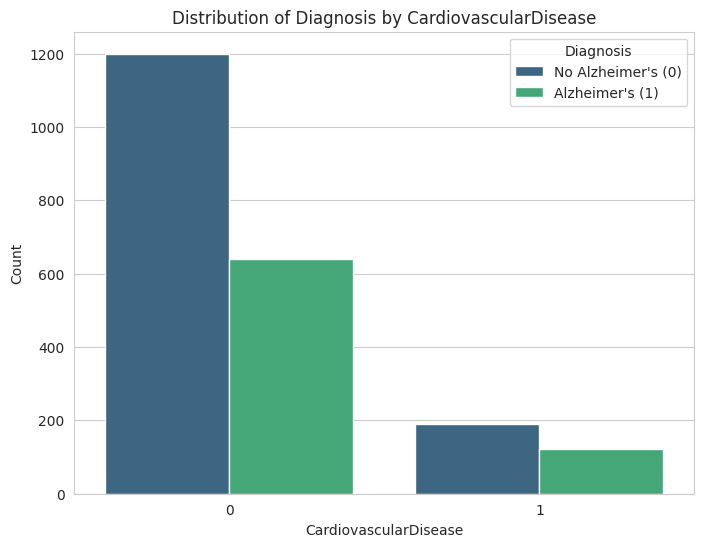

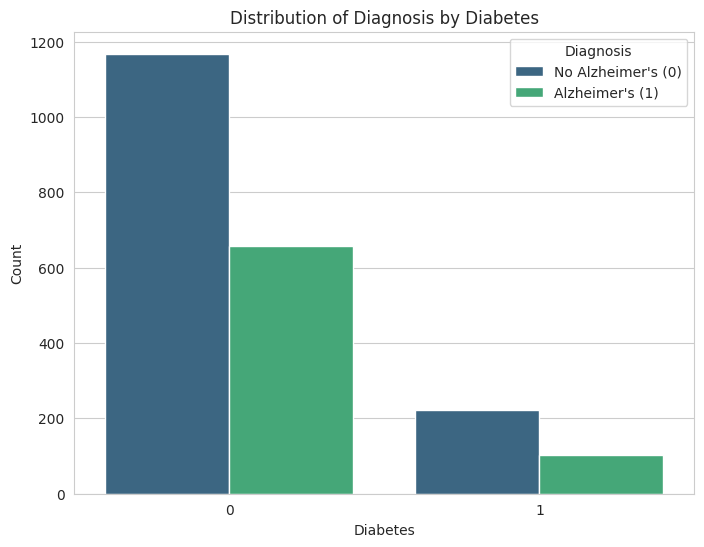

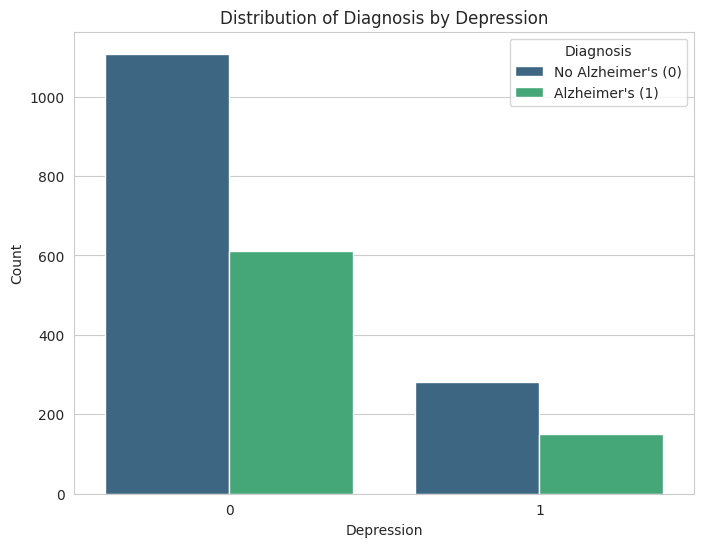

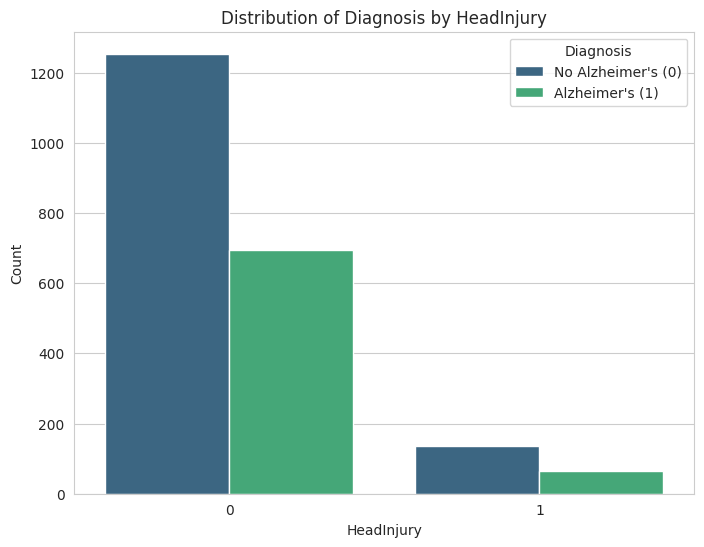

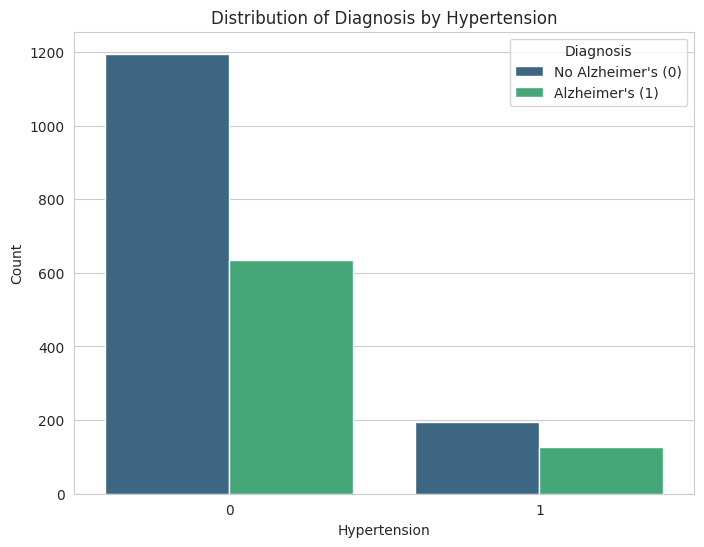

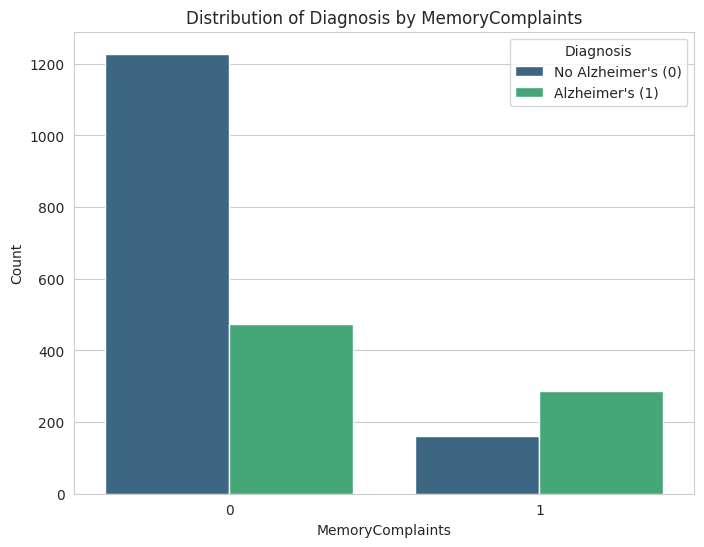

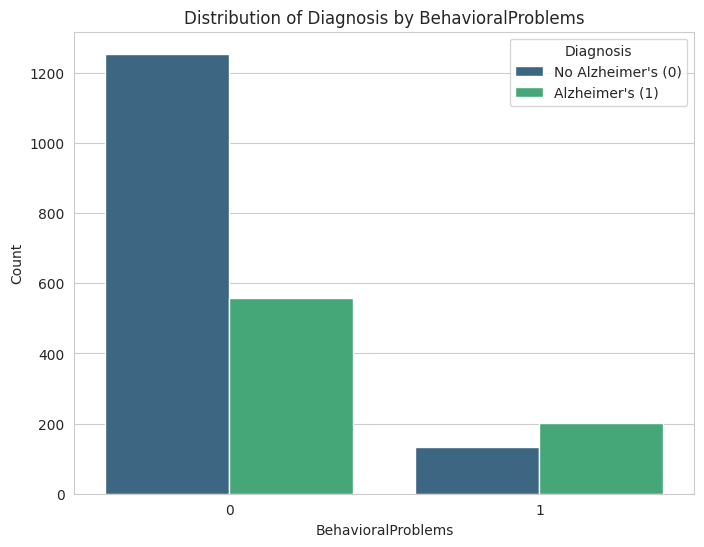

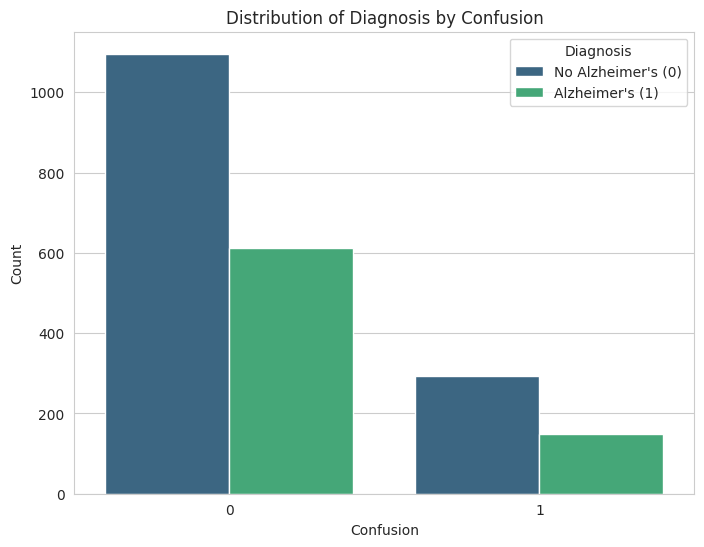

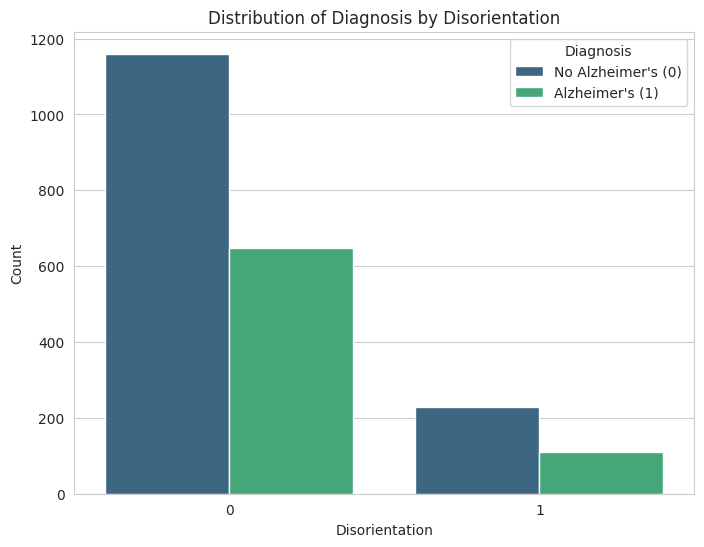

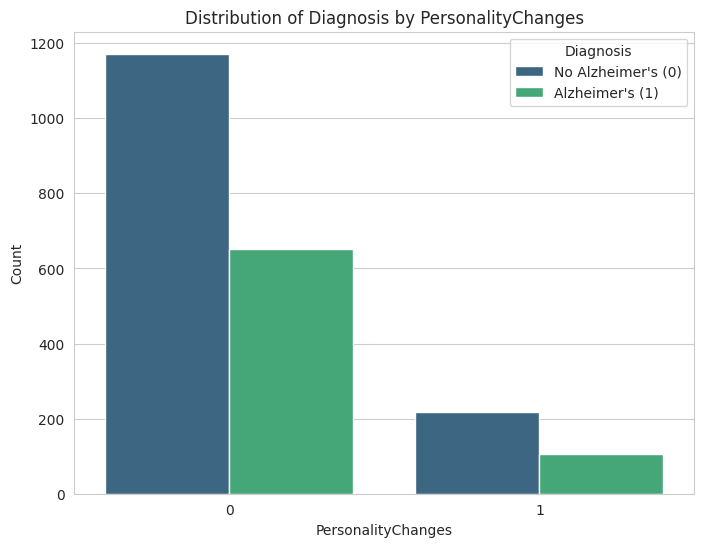

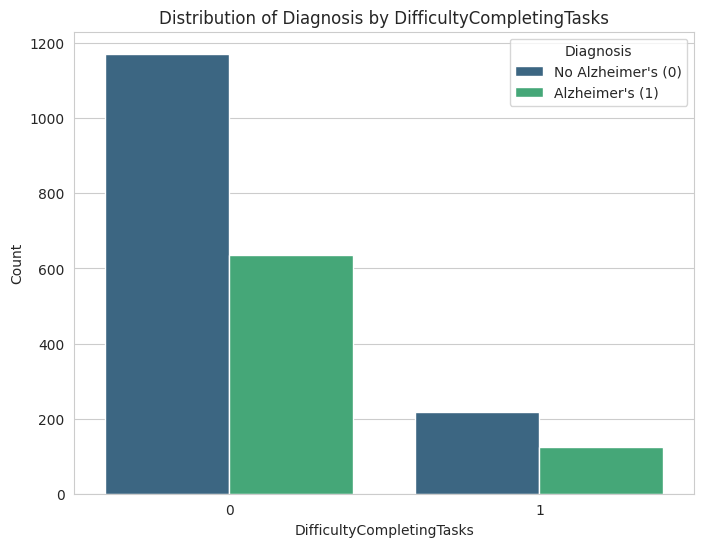

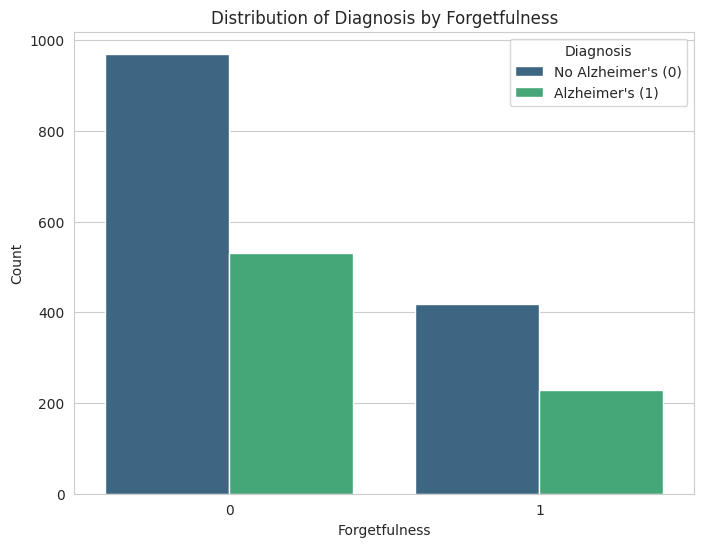

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical columns based on previous exploration (int64 dtype and unique_count <= 10)
categorical_cols_identified = []
for column in df.columns:
    if df[column].dtype == 'int64' and df[column].nunique() <= 10:
        categorical_cols_identified.append(column)

# Exclude specified columns that are not truly categorical despite meeting the criteria
exclude_cols = ['PatientID', 'Age', 'SystolicBP', 'DiastolicBP']
categorical_cols = [col for col in categorical_cols_identified if col not in exclude_cols]

# Remove 'Diagnosis' from the list if it's there, as it's the target variable
if 'Diagnosis' in categorical_cols:
    categorical_cols.remove('Diagnosis')

print(f"Identified categorical columns for plotting: {categorical_cols}")

# Create stacked bar plots for each categorical feature against 'Diagnosis'
for column in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=column, hue='Diagnosis', palette='viridis')
    plt.title(f'Distribution of Diagnosis by {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Diagnosis', labels=['No Alzheimer\'s (0)', 'Alzheimer\'s (1)'])
    plt.show()